This notebook is for testing plotting during simulations using different backends in a jupyter context. Please chose some backend using the ipython magic in the next cell and run the whole notebook with a fresh kernel.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # or 'svg'
# %matplotlib notebook
# %matplotlib osx

In [2]:
import sys

sys.path.insert(0, "/Users/dzwicker/Code/py-pde")

In [3]:
import tempfile
from pathlib import Path

import pde

# Show images during simulation
A single plot should be shown when calling the `plot` method and an animation should be displayed during the simulation. Simultaneously, a video should be created.

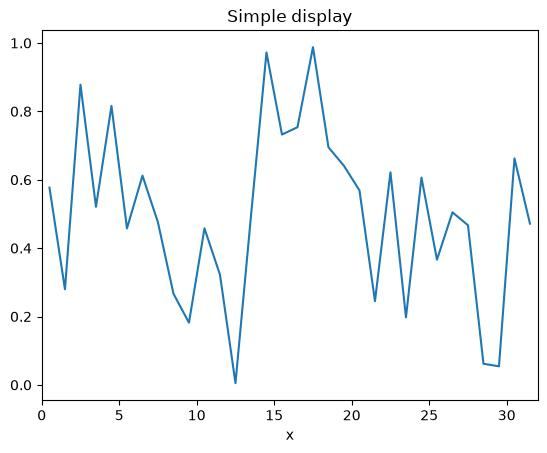

In [4]:
grid = pde.UnitGrid([32])
field = pde.ScalarField.random_uniform(grid)
field.plot(title="Simple display");

In [5]:
eq = pde.DiffusionPDE()
with tempfile.NamedTemporaryFile(delete=False, suffix=".mov") as movie_file:
    plot_tracker = pde.PlotTracker(
        0.1, title="Visible – {time:.2g}", show=True, movie=movie_file.name
    )
    _, info = eq.solve(
        field,
        t_range=2,
        dt=0.1,
        backend="numpy",
        ret_info=True,
        tracker=["progress", plot_tracker],
    )

    assert Path(movie_file.name).stat().st_size > 0

  0%|          | 0/2.0 [00:00<?, ?it/s]

Output()

In [6]:
plot_tracker._context

In [7]:
print(f"Plotting took {info['controller']['profiler']['tracker']:.3g} seconds")

Plotting took 0.807 seconds


# Don't show images during simulation

No plots should be produced, but the video should still be there.

In [8]:
grid = pde.UnitGrid([32])
field = pde.ScalarField.random_uniform(grid)
field.plot(title="Hidden display", action="close");

In [9]:
eq = pde.DiffusionPDE()
with tempfile.NamedTemporaryFile(delete=False, suffix=".mov") as movie_file:
    plot_tracker = pde.PlotTracker(
        0.1, title="Hidden – {time:.2g}", show=False, movie=movie_file.name
    )
    _, info = eq.solve(
        field,
        t_range=2,
        dt=0.1,
        backend="numpy",
        ret_info=True,
        tracker=["progress", plot_tracker],
    )

    assert Path(movie_file.name).stat().st_size > 0
    print("All done")

  0%|          | 0/2.0 [00:00<?, ?it/s]

All done


In [10]:
print(f"Plotting took {info['controller']['profiler']['tracker']:.3g} seconds")

Plotting took 0.412 seconds


# 2D collection with colorbar
A plot collection with colorbars should be shown when calling the `plot` method and an animation should be displayed during the simulation. Simultaneously, a video should be created.

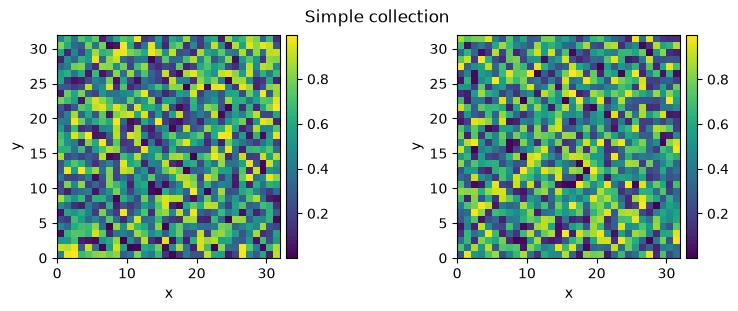

In [11]:
grid = pde.UnitGrid([32, 32])
f1 = pde.ScalarField.random_uniform(grid)
f2 = pde.ScalarField.random_uniform(grid)
fc = pde.FieldCollection([f1, f2])
fc.plot(title="Simple collection", colorbar=True);

In [12]:
eq = pde.PDE({"a": "laplace(a)", "b": "laplace(b)"})
with tempfile.NamedTemporaryFile(delete=False, suffix=".mov") as movie_file:
    plot_tracker = pde.PlotTracker(
        0.5,
        title="Visible Plot Collection – {time:.2g}",
        show=True,
        movie=movie_file.name,
        plot_args={"colorbar": True},
    )
    _, info = eq.solve(
        fc,
        t_range=2,
        dt=0.1,
        backend="numpy",
        ret_info=True,
        tracker=["progress", plot_tracker],
    )

    assert Path(movie_file.name).stat().st_size > 0

  0%|          | 0/2.0 [00:00<?, ?it/s]

Output()

In [13]:
print(f"Plotting took {info['controller']['profiler']['tracker']:.3g} seconds")

Plotting took 0.626 seconds
